In [1]:
import os
import glob
import shutil
import librosa
import numpy as np
import tensorflow as tf
import cv2
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [2]:
# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Read the metadata file and store labels
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the full undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'


In [3]:
# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Filter only the files with labels in the metadata
valid_audio_files = []
valid_labels = []

for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract identifier before extension
    
    if file_identifier in labels:
        valid_audio_files.append(audio_file)
        valid_labels.append(labels[file_identifier])  # Store "spoof" or "bonafide"


In [4]:
# Set new directory for 10% subset
subset_dir = r'D:\audio_files\undersampled_audio_10_percent'
os.makedirs(subset_dir, exist_ok=True)

# Calculate subset size (10%)
subset_size = int(0.1 * len(valid_audio_files))

# Separate files by label for balanced selection
spoof_files = [file for file, label in zip(valid_audio_files, valid_labels) if label == 'spoof']
bonafide_files = [file for file, label in zip(valid_audio_files, valid_labels) if label == 'bonafide']

# Get 5% from each class for a balanced 10%
selected_spoof_files = spoof_files[:subset_size // 2]
selected_bonafide_files = bonafide_files[:subset_size // 2]

# Combine selected files
selected_files = selected_spoof_files + selected_bonafide_files

# Copy files to new subset directory
for file_path in selected_files:
    shutil.copy(file_path, subset_dir)


KeyboardInterrupt: 

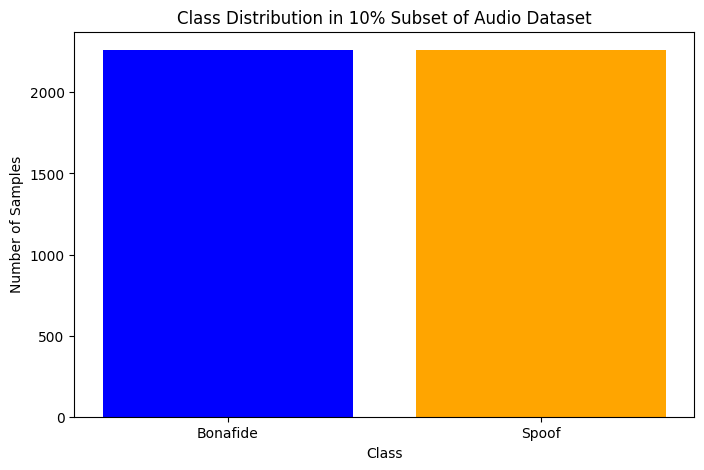

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Reload the labels for the subset to confirm the balanced distribution
subset_labels = [labels[os.path.basename(file).split('.')[0]] for file in selected_files]

# Count the occurrences of each class label
label_counts = Counter(subset_labels)

# Plot the distribution of classes
plt.figure(figsize=(8, 5))
plt.bar(label_counts.keys(), label_counts.values(), color=['blue', 'orange'])
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in 10% Subset of Audio Dataset')
plt.xticks(ticks=[0, 1], labels=['Bonafide', 'Spoof'])
plt.show()


In [6]:
# Update directory path to point to the 10% subset
undersampled_audio_dir = subset_dir

# Reload files and labels for the new subset directory
subset_audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))
subset_labels = [labels[os.path.basename(file).split('.')[0]] for file in subset_audio_files]

# Convert labels to binary format (1 for spoof, 0 for bonafide)
subset_labels = [1 if label == 'spoof' else 0 for label in subset_labels]


In [7]:
def audio_to_mfcc(audio_file, sr=16000, n_mfcc=13):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    return cv2.resize(spectrogram, target_size)

def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    mfcc_data = []
    label_data = []
    
    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        normalized_mfcc = resized_mfcc / np.max(resized_mfcc) if np.max(resized_mfcc) > 0 else resized_mfcc
        mfcc_data.append(normalized_mfcc)
        label_data.append(label)
    
    return np.array(mfcc_data), np.array(label_data)

# Preprocess subset audio files
X, y = preprocess_audio_files(subset_audio_files, subset_labels, target_size=(128, 128))

# Add channel dimension
X = np.expand_dims(X, axis=-1)


In [8]:
def stratified_split_70_15_15(X, y, random_state=42):
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=random_state)
    for train_idx, temp_idx in strat_split.split(X, y):
        X_train, X_temp = X[train_idx], X[temp_idx]
        y_train, y_temp = y[train_idx], y[temp_idx]

    strat_split_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=random_state)
    for val_idx, test_idx in strat_split_2.split(X_temp, y_temp):
        X_val, X_test = X_temp[val_idx], X_temp[test_idx]
        y_val, y_test = y_temp[val_idx], y_temp[test_idx]

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_70_15_15(X, y)


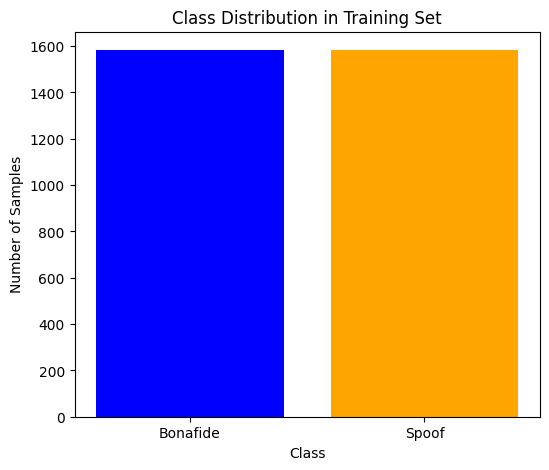

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences in the training set
train_counts = Counter(y_train)

# Prepare labels and values for plotting
labels = ['Bonafide', 'Spoof']
train_values = [train_counts[0], train_counts[1]]

# Plotting
plt.figure(figsize=(6, 5))
plt.bar(labels, train_values, color=['blue', 'orange'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()


In [10]:
def build_cnn(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape
input_shape = (128, 128, 1)
model = build_cnn(input_shape)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=4, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 279ms/step - accuracy: 0.7184 - loss: 0.5559 - val_accuracy: 0.7478 - val_loss: 0.5379
Epoch 2/4
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 288ms/step - accuracy: 0.7810 - loss: 0.4732 - val_accuracy: 0.7640 - val_loss: 0.5183
Epoch 3/4
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 298ms/step - accuracy: 0.8070 - loss: 0.4312 - val_accuracy: 0.7684 - val_loss: 0.5033
Epoch 4/4
99/99 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step - accuracy: 0.8190 - loss: 0.4123 - val_accuracy: 0.7743 - val_loss: 0.4941


22/22 - 1s - 63ms/step - accuracy: 0.7879 - loss: 0.4536
Test accuracy: 0.7879233956336975


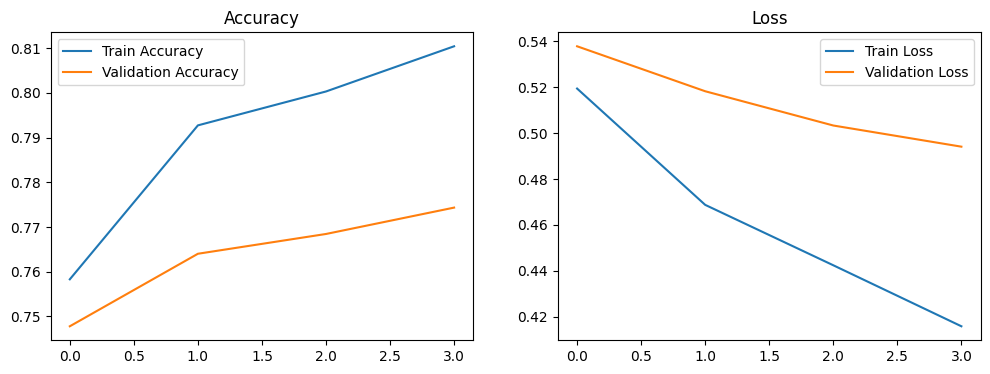

In [11]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

# Plot accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [12]:
# After training is complete, evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7867 - loss: 0.4516
Test loss: 0.45364803075790405
Test accuracy: 0.7879233956336975


In [18]:
model.save('test.keras')


In [ ]:
import numpy as np
import librosa
import cv2  # Ensure OpenCV is imported for resizing
from tensorflow.keras.models import load_model

# Load the trained model (change path as needed)
model_path = 'test.keras'
model = load_model(model_path)

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

def preprocess_audio(file_path, sr=22050, n_mfcc=13):
    """Load the audio file and extract MFCC features."""
    # Load the entire audio file
    audio, _ = librosa.load(file_path, sr=sr)
    
    # Extract MFCC features for the entire audio
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    
    # Resize MFCC to fixed size
    mfcc_resized = resize_spectrogram(mfcc, target_size=(128, 128))
    
    # Add a batch dimension to match model input shape
    mfcc_resized = np.expand_dims(mfcc_resized, axis=0)
    
    return mfcc_resized

def predict_audio_file(file_path):
    """Predict if a single audio file is a deepfake or bonafide."""
    try:
        # Preprocess the audio file
        preprocessed_audio = preprocess_audio(file_path)
        
        # Make prediction
        prediction = model.predict(preprocessed_audio)

        # Get predicted probability and class
        predicted_probability = prediction[0][0]  # Probability of the positive class (e.g., spoof)
        predicted_class = 1 if predicted_probability > 0.5 else 0  # Adjust threshold if needed

        # Convert probability to percentage
        predicted_percentage = predicted_probability * 100  # Convert to percentage

        # Display the result
        print(f"File: {file_path}, Predicted Class: {'Spoof' if predicted_class == 1 else 'Bonafide'}, Confidence: {predicted_percentage:.2f}%")

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Path to the single audio file
file_path = r"C:\Users\Hariz\Downloads\fakeyou_6m3yreh4w07azyne826h0kdkmbn7tfre.wav"  # Change this to your file path
predict_audio_file(file_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
File: C:\Users\Hariz\Downloads\fakeyou_6m3yreh4w07azyne826h0kdkmbn7tfre.wav, Predicted Class: Spoof, Confidence: 100.00%
